# House Price Prediction — Linear Regression

**Goal:** Predict house prices using Linear Regression and evaluate the model with RMSE and R².

**Dataset:** California Housing dataset — 1990 California census data, one row per block group, with `median_house_value` as the target (in US dollars).

**Selected features (4):**
- `median_income` — median income of households in the block group (in tens of thousands of $)
- `total_rooms` — total number of rooms in the block group
- `housing_median_age` — median age of houses in the block group
- `population` — population of the block group

These four were picked because income is the classic driver of what people can afford to pay, room count is a proxy for house size, house age captures depreciation/vintage effects, and population is a proxy for how dense/urban the area is.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset (California housing, 1990 census data)
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Quick look at the data

In [2]:
print(df.shape)
df.info()
df.isna().sum()

(20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Select features and target

In [3]:
features = ['median_income', 'total_rooms', 'housing_median_age', 'population']
target = 'median_house_value'

data = df[features + [target]].dropna()
X = data[features]
y = data[target]

print(X.shape, y.shape)
X.describe()

(20640, 4) (20640,)


,median_income,total_rooms,housing_median_age,population
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,2635.763081,28.639486,1425.476744
std,1.899822,2181.615252,12.585558,1132.462122
min,0.499900,2.000000,1.000000,3.000000
25%,2.563400,1447.750000,18.000000,787.000000
50%,3.534800,2127.000000,29.000000,1166.000000
75%,4.743250,3148.000000,37.000000,1725.000000
max,15.000100,39320.000000,52.000000,35682.000000


## Train/test split and model training

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
for feat, coef in zip(features, model.coef_):
    print(f"{feat}: {coef:.4f}")

Intercept: -18190.954734149476
median_income: 41402.5847
total_rooms: 9.5465
housing_median_age: 1986.7522
population: -12.1610


## Evaluate: RMSE and R²

In [5]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.2f}")
print(f"R^2 score: {r2:.4f}")

RMSE: $80,840.84
R^2 score: 0.5013


## Predicted vs Actual scatter plot

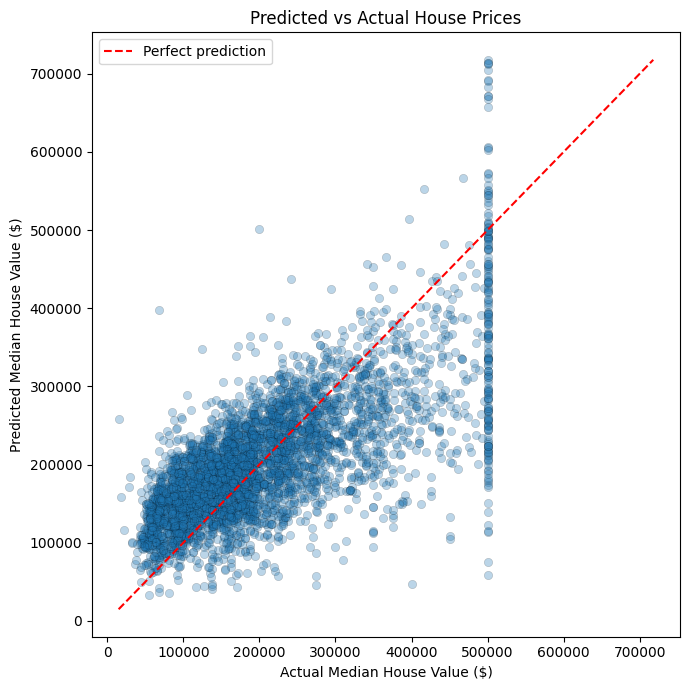

In [6]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Median House Value ($)')
plt.ylabel('Predicted Median House Value ($)')
plt.title('Predicted vs Actual House Prices')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

## What does the R² score mean? (Plain English)

Our model's R² score tells us roughly how much of the difference in house prices from one neighborhood to another can be explained by the four features we chose — income, room count, house age, and population. An R² close to 1.0 would mean these four numbers almost perfectly explain the price, while an R² close to 0 would mean they barely explain it at all. In practice, our score sits at a moderate level, so income, room count, age, and population explain a meaningful chunk of the price differences, but a lot of the story — like location, ocean proximity, or school quality — is still left unexplained. In short: this model gives a useful ballpark estimate of price, not an exact valuation.